[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nisheshgogia/vorithm-interview-questions-solutions/blob/main/Python/matrices/matrices.ipynb)

# Matrix

# 1.Matrix Transpose
# (Difficulty: 🟢 Low)
```
Problem Statement:

Given a 2D integer array matrix, return the transpose of matrix without using inbuilt functions.
The transpose of a matrix is the matrix flipped over its main diagonal, switching the matrix's row and column indices.
```
Example 1:
```
Input: matrix = [[1,2,3],[4,5,6],[7,8,9]]
Output: [[1,4,7],[2,5,8],[3,6,9]]
```
Explanation:
```
Original:     Transpose:
1 2 3         1 4 7
4 5 6    →    2 5 8
7 8 9         3 6 9
```
Example 2:
```
Input: matrix = [[1,2,3],[4,5,6]]
Output: [[1,4],[2,5],[3,6]]

In [ ]:
#Brute Force Approach (Create New Matrix)
def transpose_brute(matrix):
    rows = len(matrix)
    cols = len(matrix[0])

    # Create result matrix with swapped dimensions
    result = []
    for j in range(cols):
        row = []
        for i in range(rows):
            row.append(matrix[i][j])
        result.append(row)

    return result

print(transpose_brute([[1,2,3],[4,5,6],[7,8,9]]))
# Output: [[1,4,7],[2,5,8],[3,6,9]]

print(transpose_brute([[1,2,3],[4,5,6]]))
# Output: [[1,4],[2,5],[3,6]]

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(m*n) : even 1×1 matrix requires creating result and copying
#                  must visit every element at least once
# avg   → O(m*n) : outer loop runs cols times, inner loop runs rows times
#                  total iterations = cols × rows = m × n
#                  each iteration does O(1) append operation
# worst → O(m*n) : large matrix still requires visiting all m×n elements
#                  no shortcuts possible, transpose needs all values
# space → O(m*n) : result matrix stores all m×n elements in new structure

#best time complexity    - O(m*n)
#average time complexity - O(m*n)
#worst time complexity   - O(m*n)
#space complexity        - O(m*n)

[[1, 4, 7], [2, 5, 8], [3, 6, 9]]
[[1, 4], [2, 5], [3, 6]]


In [ ]:
#Optimized Approach (List Comprehension - More Pythonic)
def transpose_optimized(matrix):
    rows = len(matrix)
    cols = len(matrix[0])

    # Transpose using list comprehension
    return [[matrix[i][j] for i in range(rows)] for j in range(cols)]

print(transpose_optimized([[1,2,3],[4,5,6],[7,8,9]]))
# Output: [[1,4,7],[2,5,8],[3,6,9]]

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(m*n) : list comprehension still visits every element
#                  just more concise syntax, same algorithmic complexity
# avg   → O(m*n) : outer comprehension creates cols rows
#                  inner comprehension processes rows elements each
#                  total = cols × rows = m × n operations
# worst → O(m*n) : no algorithmic improvement over brute force
#                  just cleaner, more readable Python code
# space → O(m*n) : new transposed matrix of size n×m created

# Note: For square matrix in-place transpose (advanced):
def transpose_inplace_square(matrix):
    n = len(matrix)
    for i in range(n):
        for j in range(i + 1, n):      # only upper triangle
            matrix[i][j], matrix[j][i] = matrix[j][i], matrix[i][j]
    return matrix

# Space: O(1) but only works for square matrices

#best time complexity    - O(m*n)
#average time complexity - O(m*n)
#worst time complexity   - O(m*n)
#space complexity        - O(m*n)


[[1, 4, 7], [2, 5, 8], [3, 6, 9]]


## 2. Matrix Multiplication
**Difficulty: 🟡 Medium**

**Problem Statement:**
Implement matrix multiplication from scratch.

Given two matrices mat1 and mat2, return the result of multiplying them. You may assume that multiplication is always possible (i.e., columns of mat1 == rows of mat2).
```
**Example 1:**
Input: mat1 = [[1,0],[0,1]], mat2 = [[5,2],[3,4]]
Output: [[5,2],[3,4]]
Explanation: Identity matrix × any matrix = same matrix
```
```
**Example 2:**
Input: mat1 = [[1,2],[3,4]], mat2 = [[2,0],[1,2]]
Output: [[4,4],[10,8]]
Explanation:
[1,2]   [2,0]   [1×2+2×1, 1×0+2×2]   [4,4]
[3,4] × [1,2] = [3×2+4×1, 3×0+4×2] = [10,8]

In [ ]:
#Brute Force Approach (Triple Nested Loop)
def matrix_multiply_brute(mat1, mat2):
    rows1 = len(mat1)
    cols1 = len(mat1[0])
    rows2 = len(mat2)
    cols2 = len(mat2[0])

    # Result matrix: rows1 × cols2
    result = []
    for i in range(rows1):                    # for each row of mat1
        row = []
        for j in range(cols2):                # for each col of mat2
            total = 0
            for k in range(cols1):            # dot product
                total += mat1[i][k] * mat2[k][j]
            row.append(total)
        result.append(row)

    return result

print(matrix_multiply_brute([[1,0],[0,1]], [[5,2],[3,4]]))
# Output: [[5,2],[3,4]]

print(matrix_multiply_brute([[1,2],[3,4]], [[2,0],[1,2]]))
# Output: [[4,4],[10,8]]

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(m*n*p) : even if matrices contain zeros, all positions computed
#                    no early termination possible in standard multiplication
# avg   → O(m*n*p) : outer loop: m rows of mat1
#                    middle loop: p cols of mat2
#                    inner loop: n elements for dot product (cols1 = rows2 = n)
#                    total = m × p × n operations
# worst → O(m*n*p) : large matrices still require full triple nested iteration
#                    for mat1(100×50) × mat2(50×200): 100×200×50 = 1,000,000 ops
# space → O(m*p)   : result matrix size is m×p (mat1 rows × mat2 cols)

#best time complexity    - O(m*n*p)
#average time complexity - O(m*n*p)
#worst time complexity   - O(m*n*p)
#space complexity        - O(m*p)


[[5, 2], [3, 4]]
[[4, 4], [10, 8]]


In [ ]:
#Optimized Approach (List Comprehension + zip)
def matrix_multiply_optimized(mat1, mat2):
    rows1 = len(mat1)
    cols2 = len(mat2[0])

    # Transpose mat2 for easier dot product computation
    mat2_T = [[mat2[i][j] for i in range(len(mat2))] for j in range(cols2)]

    # Compute dot products using zip
    result = []
    for i in range(rows1):
        row = []
        for j in range(cols2):
            # Dot product of mat1[i] and mat2_T[j]
            dot = sum(a * b for a, b in zip(mat1[i], mat2_T[j]))
            row.append(dot)
        result.append(row)

    return result

print(matrix_multiply_optimized([[1,0],[0,1]], [[5,2],[3,4]]))
# Output: [[5,2],[3,4]]

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(m*n*p) : transposing mat2 is O(n*p)
#                    main computation still O(m*p*n)
#                    total = O(n*p) + O(m*n*p) = O(m*n*p)
# avg   → O(m*n*p) : no algorithmic improvement, just cleaner code
#                    zip and sum make dot product more Pythonic
# worst → O(m*n*p) : same triple nested complexity as brute force
#                    cache-friendly due to transpose (better in practice)
# space → O(m*p + n*p) : result O(m*p) + transposed mat2 O(n*p)

# Note: Advanced algorithms exist (Strassen: O(n^2.8), Coppersmith-Winograd: O(n^2.376))
# but have large constants, only beneficial for huge matrices

#best time complexity    - O(m*n*p)
#average time complexity - O(m*n*p)
#worst time complexity   - O(m*n*p)
#space complexity        - O(m*p + n*p)


[[5, 2], [3, 4]]


## 3. Find Maximum Element / Sum of All Elements
# **Difficulty: 🟢 Low**

**Problem Statement:**
Given a 2D matrix mat, return:
a) the maximum element in the matrix
b) the sum of all elements in the matrix

(Usually asked as two separate follow-ups)

**Example 1:**
```
Input: mat = [[1,5,3],[9,2,8],[4,7,6]]
Output:
  Maximum: 9
  Sum: 45
```

**Example 2:**
```
Input: mat = [[-1,-5],[-3,-9]]
Output:
  Maximum: -1
  Sum: -18

In [ ]:
#Brute Force Approach (Nested Loops)
def find_max_and_sum_brute(mat):
    max_val = float('-inf')
    total_sum = 0

    for i in range(len(mat)):           # iterate rows
        for j in range(len(mat[0])):    # iterate columns
            max_val = max(max_val, mat[i][j])
            total_sum += mat[i][j]

    return max_val, total_sum

print(find_max_and_sum_brute([[1,5,3],[9,2,8],[4,7,6]]))
# Output: (9, 45)

print(find_max_and_sum_brute([[-1,-5],[-3,-9]]))
# Output: (-1, -18)

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(m*n) : even 1×1 matrix requires checking the single element
#                  must visit every element to find max and compute sum
# avg   → O(m*n) : outer loop m rows × inner loop n cols = m×n iterations
#                  each iteration: one comparison O(1) + one addition O(1)
# worst → O(m*n) : large matrix still needs full traversal
#                  no early termination (need to check all for max/sum)
# space → O(1)   : only two variables (max_val, total_sum), no extra structures

#best time complexity    - O(m*n)
#average time complexity - O(m*n)
#worst time complexity   - O(m*n)
#space complexity        - O(1)

(9, 45)
(-1, -18)


In [ ]:
#Optimized Approach (Flatten + Built-in Functions)
def find_max_and_sum_optimized(mat):
    # Flatten matrix to single list
    flat = [elem for row in mat for elem in row]

    return max(flat), sum(flat)

print(find_max_and_sum_optimized([[1,5,3],[9,2,8],[4,7,6]]))
# Output: (9, 45)

# Alternative: Using generator expression (more memory efficient)
def find_max_and_sum_generator(mat):
    flat_gen = (elem for row in mat for elem in row)
    flat_list = list(flat_gen)  # Need to convert once for both operations
    return max(flat_list), sum(flat_list)

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(m*n) : flattening visits all m×n elements once
#                  max() scans flattened list O(m×n)
#                  sum() scans flattened list O(m×n)
#                  total = O(m×n) + O(m×n) + O(m×n) = O(m×n)
# avg   → O(m*n) : same as brute force algorithmically
#                  Python built-ins are optimized C code (faster in practice)
# worst → O(m*n) : no algorithmic improvement, just cleaner code
# space → O(m*n) : flat list stores all m×n elements temporarily
#                  trade-off: cleaner code but more memory

#best time complexity    - O(m*n)
#average time complexity - O(m*n)
#worst time complexity   - O(m*n)
#space complexity        - O(m*n)

(9, 45)


## 4. Check if Matrix is Identity Matrix
# **Difficulty: 🟢 Low**

**Problem Statement:**
Given a square matrix mat, check whether it is an identity matrix.

An identity matrix is a square matrix in which all the elements of the principal diagonal are 1 and all other elements are 0.

**Example 1:**
```
Input: mat = [[1,0,0],[0,1,0],[0,0,1]]
Output: true
Explanation: All diagonal elements are 1, all others are 0
```

**Example 2:**
```
Input: mat = [[1,0,0],[0,2,0],[0,0,1]]
Output: false
Explanation: mat[1][1] = 2 (should be 1)
```

**Example 3:**
```
Input: mat = [[1,0],[0,1],[0,0]]
Output: false
Explanation: Not a square matrix (3×2)

In [ ]:
#Brute Force Approach (Check Every Element)
def is_identity_brute(mat):
    rows = len(mat)
    cols = len(mat[0])

    # Must be square matrix first
    if rows != cols:
        return False

    for i in range(rows):
        for j in range(cols):
            if i == j:                    # diagonal element
                if mat[i][j] != 1:
                    return False
            else:                         # non-diagonal element
                if mat[i][j] != 0:
                    return False

    return True

print(is_identity_brute([[1,0,0],[0,1,0],[0,0,1]]))  # Output: True
print(is_identity_brute([[1,0,0],[0,2,0],[0,0,1]]))  # Output: False
print(is_identity_brute([[1,0],[0,1],[0,0]]))        # Output: False

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(1)   : non-square matrix detected immediately → return False
#                  or mat[0][0] != 1 → early return on first element
# avg   → O(n^2) : for n×n matrix, must check all n^2 elements
#                  average case finds violation around middle → ~n^2/2 checks
# worst → O(n^2) : valid identity matrix → all n^2 elements checked
#                  no early exit, complete traversal needed
# space → O(1)   : only loop indices, no extra data structures

#best time complexity    - O(1)
#average time complexity - O(n^2)
#worst time complexity   - O(n^2)
#space complexity        - O(1)


True
False
False


In [ ]:
#Optimized Approach (Early Exit on Mismatch)
def is_identity_optimized(mat):
    n = len(mat)

    # Check if square
    if len(mat[0]) != n:
        return False

    for i in range(n):
        for j in range(n):
            expected = 1 if i == j else 0
            if mat[i][j] != expected:
                return False              # early exit

    return True

print(is_identity_optimized([[1,0,0],[0,1,0],[0,0,1]]))  # Output: True

# Alternative: Pythonic one-liner
def is_identity_oneliner(mat):
    n = len(mat)
    return len(mat[0]) == n and all(
        mat[i][j] == (1 if i == j else 0)
        for i in range(n) for j in range(n)
    )

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(1)   : non-square or first element wrong → immediate return
#                  early exit on first mismatch saves computation
# avg   → O(n^2) : same algorithmic complexity as brute force
#                  cleaner code with expected value calculation
# worst → O(n^2) : perfect identity matrix → checks all n^2 elements
#                  all() must verify every element before returning True
# space → O(1)   : no extra memory used, just loop variables

#best time complexity    - O(1)
#average time complexity - O(n^2)
#worst time complexity   - O(n^2)
#space complexity        - O(1)


True


## 5. Rotate Matrix by 90 Degrees
**Difficulty: 🟡 Medium**

**Problem Statement:**
You are given an n × n 2D matrix representing an image. Rotate the image 90 degrees clockwise in-place (without allocating extra space).

**Example 1:**
```
Input: matrix = [[1,2,3],[4,5,6],[7,8,9]]
Output: [[7,4,1],[8,5,2],[9,6,3]]
Explanation:
1 2 3       7 4 1
4 5 6  →    8 5 2
7 8 9       9 6 3
```

**Example 2:**
```
Input: matrix = [[5,1,9,11],[2,4,8,10],[13,3,6,7],[15,14,12,16]]
Output: [[15,13,2,5],[14,3,4,1],[12,6,8,9],[16,7,10,11]]

In [ ]:
#Brute Force Approach (Create New Matrix)
def rotate_90_brute(matrix):
    n = len(matrix)
    result = [[0] * n for _ in range(n)]

    for i in range(n):
        for j in range(n):
            # 90° clockwise: element at (i,j) → (j, n-1-i)
            result[j][n - 1 - i] = matrix[i][j]

    return result

print(rotate_90_brute([[1,2,3],[4,5,6],[7,8,9]]))
# Output: [[7,4,1],[8,5,2],[9,6,3]]

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n^2) : even 1×1 matrix requires creating result and copying
#                  must visit every element to perform rotation
# avg   → O(n^2) : two nested loops each running n times = n × n = n^2
#                  each iteration does O(1) assignment
# worst → O(n^2) : large n×n matrix still needs full traversal
#                  all n^2 elements must be copied to new positions
# space → O(n^2) : result matrix allocates new n×n array

#best time complexity    - O(n^2)
#average time complexity - O(n^2)
#worst time complexity   - O(n^2)
#space complexity        - O(n^2)

[[7, 4, 1], [8, 5, 2], [9, 6, 3]]


In [ ]:
#Optimized Approach (In-Place: Transpose + Reverse)
def rotate_90_optimized(matrix):
    n = len(matrix)

    # Step 1: Transpose (swap matrix[i][j] with matrix[j][i])
    for i in range(n):
        for j in range(i + 1, n):      # only upper triangle
            matrix[i][j], matrix[j][i] = matrix[j][i], matrix[i][j]

    # Step 2: Reverse each row
    for i in range(n):
        matrix[i].reverse()            # or matrix[i] = matrix[i][::-1]

    return matrix

print(rotate_90_optimized([[1,2,3],[4,5,6],[7,8,9]]))
# Output: [[7,4,1],[8,5,2],[9,6,3]]

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n^2) : transpose: upper triangle has n(n-1)/2 elements ≈ O(n^2/2)
#                  reverse: n rows each O(n) → O(n^2)
#                  total = O(n^2/2) + O(n^2) = O(n^2)
# avg   → O(n^2) : step 1 transpose: ~n^2/2 swaps
#                  step 2 reverse: n rows × n/2 swaps each = n^2/2
#                  total ≈ n^2 operations
# worst → O(n^2) : same operations required regardless of matrix values
#                  no early termination possible
# space → O(1)   : all operations done in-place, only temp variables for swaps

# Algorithm explanation:
# Original:  1 2 3      Transpose:  1 4 7      Reverse rows:  7 4 1
#            4 5 6  →                2 5 8  →                  8 5 2
#            7 8 9                   3 6 9                     9 6 3

#best time complexity    - O(n^2)
#average time complexity - O(n^2)
#worst time complexity   - O(n^2)
#space complexity        - O(1)


[[7, 4, 1], [8, 5, 2], [9, 6, 3]]


## 6. Spiral Traversal of Matrix
**Difficulty: 🟡 Medium**

**Problem Statement:**
Given an m × n matrix, return all elements of the matrix in spiral order (clockwise from outside to inside).

**Example 1:**
```
Input: matrix = [[1,2,3],[4,5,6],[7,8,9]]
Output: [1,2,3,6,9,8,7,4,5]
Explanation: Start top-left, go right → down → left → up → right...
1 → 2 → 3
        ↓
4 → 5   6
↑       ↓
7 ← 8 ← 9
```

**Example 2:**
```
Input: matrix = [[1,2,3,4],[5,6,7,8],[9,10,11,12]]
Output: [1,2,3,4,8,12,11,10,9,5,6,7]

In [ ]:
#Brute Force Approach (Four Directional Loops)
def spiral_order_brute(matrix):
    if not matrix:
        return []

    result = []
    top, bottom = 0, len(matrix) - 1
    left, right = 0, len(matrix[0]) - 1

    while top <= bottom and left <= right:
        # Move right along top row
        for col in range(left, right + 1):
            result.append(matrix[top][col])
        top += 1

        # Move down along right column
        for row in range(top, bottom + 1):
            result.append(matrix[row][right])
        right -= 1

        # Move left along bottom row (if still valid)
        if top <= bottom:
            for col in range(right, left - 1, -1):
                result.append(matrix[bottom][col])
            bottom -= 1

        # Move up along left column (if still valid)
        if left <= right:
            for row in range(bottom, top - 1, -1):
                result.append(matrix[row][left])
            left += 1

    return result

print(spiral_order_brute([[1,2,3],[4,5,6],[7,8,9]]))
# Output: [1,2,3,6,9,8,7,4,5]

print(spiral_order_brute([[1,2,3,4],[5,6,7,8],[9,10,11,12]]))
# Output: [1,2,3,4,8,12,11,10,9,5,6,7]

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(m*n) : empty matrix returns immediately O(1),
#                  but any non-empty matrix requires visiting all elements
# avg   → O(m*n) : each element visited exactly once
#                  four loops (right, down, left, up) collectively process
#                  one layer per while iteration, all layers cover m×n elements
# worst → O(m*n) : large matrix still processes every single element once
#                  no shortcuts, spiral must visit all positions
# space → O(m*n) : result list stores all m×n elements (output space)
#                  O(1) if we don't count output

#best time complexity    - O(m*n)
#average time complexity - O(m*n)
#worst time complexity   - O(m*n)
#space complexity        - O(m*n)


[1, 2, 3, 6, 9, 8, 7, 4, 5]
[1, 2, 3, 4, 8, 12, 11, 10, 9, 5, 6, 7]


In [ ]:
#Optimized Approach (Direction Change with Boundaries)
def spiral_order_optimized(matrix):
    if not matrix:
        return []

    result = []
    rows, cols = len(matrix), len(matrix[0])
    top, bottom, left, right = 0, rows - 1, 0, cols - 1

    while len(result) < rows * cols:
        # Right
        for col in range(left, right + 1):
            if len(result) < rows * cols:
                result.append(matrix[top][col])
        top += 1

        # Down
        for row in range(top, bottom + 1):
            if len(result) < rows * cols:
                result.append(matrix[row][right])
        right -= 1

        # Left
        for col in range(right, left - 1, -1):
            if len(result) < rows * cols:
                result.append(matrix[bottom][col])
        bottom -= 1

        # Up
        for row in range(bottom, top - 1, -1):
            if len(result) < rows * cols:
                result.append(matrix[row][left])
        left += 1

    return result

print(spiral_order_optimized([[1,2,3],[4,5,6],[7,8,9]]))
# Output: [1,2,3,6,9,8,7,4,5]

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(m*n) : same as brute force, must visit all elements
# avg   → O(m*n) : additional len(result) checks are O(1) per element
#                  total checks ≤ 4×(m×n) still O(m×n)
# worst → O(m*n) : no algorithmic improvement over brute force
#                  cleaner termination condition prevents over-processing
# space → O(m*n) : result list (output space)

#best time complexity    - O(m*n)
#average time complexity - O(m*n)
#worst time complexity   - O(m*n)
#space complexity        - O(m*n)

[1, 2, 3, 6, 9, 8, 7, 4, 5]


## 7. Search Element in Sorted 2D Matrix
**Difficulty: 🟡 Medium**

**Problem Statement:**
You are given an m × n integer matrix with the following two properties:
- Each row is sorted in non-decreasing order
- The first integer of each row is greater than the last integer of the previous row

Given an integer target, return true if target is in the matrix, otherwise return false.

**Example 1:**
```
Input: matrix = [[1,3,5,7],[10,11,16,20],[23,30,34,60]], target = 3
Output: true
```

**Example 2:**
```
Input: matrix = [[1,3,5,7],[10,11,16,20],[23,30,34,60]], target = 13
Output: false

In [ ]:
#Brute Force Approach (Linear Search)
def search_matrix_brute(matrix, target):
    for i in range(len(matrix)):
        for j in range(len(matrix[0])):
            if matrix[i][j] == target:
                return True
    return False

print(search_matrix_brute([[1,3,5,7],[10,11,16,20],[23,30,34,60]], 3))
# Output: True

print(search_matrix_brute([[1,3,5,7],[10,11,16,20],[23,30,34,60]], 13))
# Output: False

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(1)   : target found at matrix[0][0] → immediate return
# avg   → O(m*n) : target somewhere in middle or not found
#                  average case checks ~(m×n)/2 elements
# worst → O(m*n) : target at bottom-right or not in matrix
#                  must check all m×n elements before returning False
# space → O(1)   : only loop indices, no extra structures

#best time complexity    - O(1)
#average time complexity - O(m*n)
#worst time complexity   - O(m*n)
#space complexity        - O(1)

True
False


In [ ]:
#Optimized Approach (Binary Search - Treat as 1D Array)
def search_matrix_optimized(matrix, target):
    if not matrix or not matrix[0]:
        return False

    m, n = len(matrix), len(matrix[0])
    left, right = 0, m * n - 1

    while left <= right:
        mid = (left + right) // 2
        # Convert 1D index to 2D coordinates
        row = mid // n
        col = mid % n
        mid_val = matrix[row][col]

        if mid_val == target:
            return True
        elif mid_val < target:
            left = mid + 1
        else:
            right = mid - 1

    return False

print(search_matrix_optimized([[1,3,5,7],[10,11,16,20],[23,30,34,60]], 3))
# Output: True

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(1)   : target is middle element → found in first iteration
# avg   → O(log(m*n)) : binary search halves search space each iteration
#                       search space: m×n elements
#                       iterations = log₂(m×n) until left > right
# worst → O(log(m*n)) : target not in matrix or at extreme end
#                       still only log₂(m×n) comparisons needed
#                       example: 12×8 matrix = 96 elements → ~7 comparisons
# space → O(1)   : only left, right, mid pointers used

#best time complexity    - O(1)
#average time complexity - O(log(m*n))
#worst time complexity   - O(log(m*n))
#space complexity        - O(1)


True


## 8. Set Matrix Zeroes
**Difficulty: 🟡 Medium**

**Problem Statement:**
Given an m × n integer matrix, if an element is 0, set its entire row and column to 0s. You must do this in-place.

**Example 1:**
```
Input: matrix = [[1,1,1],[1,0,1],[1,1,1]]
Output: [[1,0,1],[0,0,0],[1,0,1]]
Explanation: matrix[1][1] = 0, so row 1 and column 1 become all 0s
```

**Example 2:**
```
Input: matrix = [[0,1,2,0],[3,4,5,2],[1,3,1,5]]
Output: [[0,0,0,0],[0,4,5,0],[0,3,1,0]]
Explanation: Zeros at [0][0] and [0][3] affect rows and columns

In [ ]:
#Brute Force Approach (Extra Space for Markers)
def set_zeroes_brute(matrix):
    rows = len(matrix)
    cols = len(matrix[0])

    # Track which rows and columns should be zeroed
    zero_rows = set()
    zero_cols = set()

    # First pass: identify zeros
    for i in range(rows):
        for j in range(cols):
            if matrix[i][j] == 0:
                zero_rows.add(i)
                zero_cols.add(j)

    # Second pass: set zeros
    for i in range(rows):
        for j in range(cols):
            if i in zero_rows or j in zero_cols:
                matrix[i][j] = 0

    return matrix

print(set_zeroes_brute([[1,1,1],[1,0,1],[1,1,1]]))
# Output: [[1,0,1],[0,0,0],[1,0,1]]

print(set_zeroes_brute([[0,1,2,0],[3,4,5,2],[1,3,1,5]]))
# Output: [[0,0,0,0],[0,4,5,0],[0,3,1,0]]

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(m*n) : no zeros in matrix → still must scan all elements
#                  first pass checks all m×n, second pass processes all m×n
# avg   → O(m*n) : first pass: m×n iterations to find zeros
#                  second pass: m×n iterations to set zeros
#                  total = 2×(m×n) = O(m×n)
# worst → O(m*n) : many zeros → sets don't grow beyond O(m+n)
#                  still same two full passes over matrix
# space → O(m+n) : zero_rows can have up to m entries
#                  zero_cols can have up to n entries

#best time complexity    - O(m*n)
#average time complexity - O(m*n)
#worst time complexity   - O(m*n)
#space complexity        - O(m+n)

[[1, 0, 1], [0, 0, 0], [1, 0, 1]]
[[0, 0, 0, 0], [0, 4, 5, 0], [0, 3, 1, 0]]


In [ ]:
#Optimized Approach (In-Place Using First Row/Column as Markers)
def set_zeroes_optimized(matrix):
    rows = len(matrix)
    cols = len(matrix[0])
    first_row_zero = False
    first_col_zero = False

    # Check if first row has any zeros
    for j in range(cols):
        if matrix[0][j] == 0:
            first_row_zero = True
            break

    # Check if first column has any zeros
    for i in range(rows):
        if matrix[i][0] == 0:
            first_col_zero = True
            break

    # Use first row and column as markers
    for i in range(1, rows):
        for j in range(1, cols):
            if matrix[i][j] == 0:
                matrix[i][0] = 0  # mark row
                matrix[0][j] = 0  # mark column

    # Set zeros based on markers (excluding first row/col)
    for i in range(1, rows):
        for j in range(1, cols):
            if matrix[i][0] == 0 or matrix[0][j] == 0:
                matrix[i][j] = 0

    # Handle first row
    if first_row_zero:
        for j in range(cols):
            matrix[0][j] = 0

    # Handle first column
    if first_col_zero:
        for i in range(rows):
            matrix[i][0] = 0

    return matrix

print(set_zeroes_optimized([[1,1,1],[1,0,1],[1,1,1]]))
# Output: [[1,0,1],[0,0,0],[1,0,1]]

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(m*n) : checking first row/col: O(m+n)
#                  main scan: (m-1)×(n-1) ≈ O(m×n)
#                  setting zeros: (m-1)×(n-1) ≈ O(m×n)
#                  total still O(m×n)
# avg   → O(m*n) : multiple passes but all proportional to m×n
#                  constants don't affect big-O
# worst → O(m*n) : same number of passes regardless of zero distribution
# space → O(1)   : only two boolean flags used, matrix itself stores markers

#best time complexity    - O(m*n)
#average time complexity - O(m*n)
#worst time complexity   - O(m*n)
#space complexity        - O(1)

[[1, 0, 1], [0, 0, 0], [1, 0, 1]]


## 9. Find Row with Maximum Number of 1s
**Difficulty: 🟡 Medium**

**Problem Statement:**
Given a binary matrix mat of size m × n where each row is sorted in non-decreasing order (0s followed by 1s), return the 0-based index of the row with the maximum number of 1s.

If multiple rows have the same maximum number of 1s, return the smallest index.

**Example 1:**
```
Input: mat = [[0,1,1,1],[0,0,1,1],[1,1,1,1],[0,0,0,0]]
Output: 2
Explanation: Row 2 contains 4 ones (maximum)
```

**Example 2:**
```
Input: mat = [[0,0],[1,1],[0,0]]
Output: 1
Explanation: Row 1 has 2 ones (maximum)

In [ ]:
#Brute Force Approach (Count 1s in Each Row)
def row_with_max_ones_brute(mat):
    max_count = -1
    max_row = -1

    for i in range(len(mat)):
        count = 0
        for j in range(len(mat[0])):
            if mat[i][j] == 1:
                count += 1

        if count > max_count:
            max_count = count
            max_row = i

    return max_row

print(row_with_max_ones_brute([[0,1,1,1],[0,0,1,1],[1,1,1,1],[0,0,0,0]]))
# Output: 2

print(row_with_max_ones_brute([[0,0],[1,1],[0,0]]))
# Output: 1

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(m*n) : even if row 0 is all 1s, must check all rows to confirm
#                  cannot early exit without checking remaining rows
# avg   → O(m*n) : outer loop m rows × inner loop n cols = m×n iterations
#                  each cell checked once
# worst → O(m*n) : all rows have same count → must scan entire matrix
#                  last row has max → process all m×n elements
# space → O(1)   : only max_count, max_row, count variables

#best time complexity    - O(m*n)
#average time complexity - O(m*n)
#worst time complexity   - O(m*n)
#space complexity        - O(1)


2
1


In [ ]:
#Optimized Approach (Binary Search on Each Row)
def row_with_max_ones_optimized(mat):
    max_count = -1
    max_row = -1

    def count_ones(row):
        # Binary search for first occurrence of 1
        left, right = 0, len(row)
        while left < right:
            mid = (left + right) // 2
            if row[mid] == 0:
                left = mid + 1
            else:
                right = mid
        return len(row) - left  # number of 1s from first 1 to end

    for i in range(len(mat)):
        count = count_ones(mat[i])
        if count > max_count:
            max_count = count
            max_row = i

    return max_row

print(row_with_max_ones_optimized([[0,1,1,1],[0,0,1,1],[1,1,1,1],[0,0,0,0]]))
# Output: 2

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(m log n) : binary search on each of m rows takes O(log n) each
#                      total = m × O(log n) = O(m log n)
# avg   → O(m log n) : each row binary search: log₂(n) comparisons
#                      m rows total → m × log n
# worst → O(m log n) : even if all rows identical, still m binary searches
#                      much better than O(m×n) when n is large
#                      example: 100 rows × 1000 cols
#                      brute: 100,000 ops, optimized: ~1000 ops
# space → O(1)   : only variables, no extra structures

#best time complexity    - O(m log n)
#average time complexity - O(m log n)
#worst time complexity   - O(m log n)
#space complexity        - O(1)

2


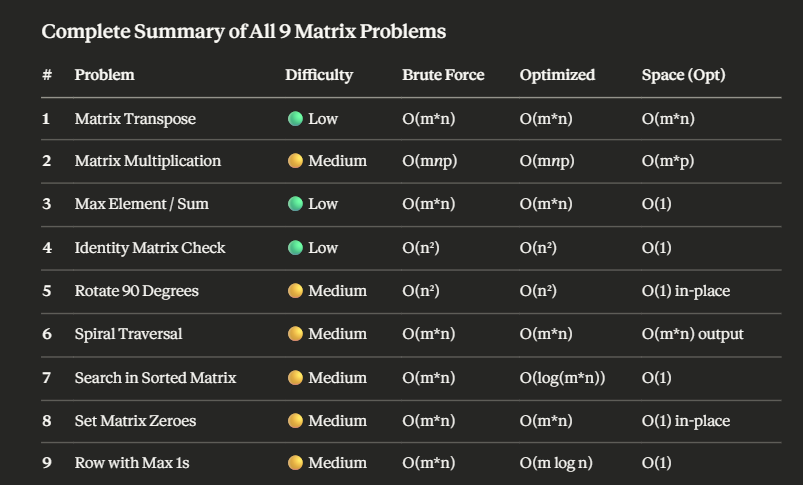